# Import and setup

In [ ]:
from google.colab import drive
import pandas as pd
import string
import requests
import io
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import ftplib as FTP

In [ ]:
#Mount google drive
#drive.mount('/content/drive')
#base_path = '/content/drive/My Drive/Group Project/'


#If running locally, uncomment this bock and comment out google drive block
base_path = '../data/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Data from NDI
https://www.cdc.gov/nchs/linked-data/mortality-files/index.html#cdc_data_surveillance_section_3-2019-public-use

In [ ]:
years = [n for n in range(1999,2018) if n%2 !=0]

def download_ndi(year):
  session = requests.Session()

  #Construct url
  url = f'https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_{year}_{year+1}_MORT_2019_PUBLIC.dat'
  r = session.get(url, stream=True)
  if r.status_code == 200: #If file exists at URL
    file = session.get(url)
    #Save file
    #print(f'---downloading: {year}-{year+1}',)
    with open(f'{base_path}MORT_{year}.dat', 'wb') as f:
      f.write(file.content)
  return session.close()

for year in years:
  download_ndi(year)

In [ ]:
def read_ndi(year):
  #Maps Variable names to position in row
  col_specs = {'SEQN': (0, 6),
 'ELIGSTAT': (14, 15),
 'MORTSTAT': (15, 16),
 'UCOD_LEADING': (16, 19),
 'DIABETES': (19, 20),
 'HYPERTEN': (20, 21),
 'PERMTH_INT': (42, 45),
 'PERMTH_EXM': (45, 48)}

  #Read as fixed-width-file
  df = pd.read_fwf(f'{base_path}MORT_{year}.dat',
              colspecs=list(col_specs.values()),
              names=list(col_specs.keys()))

  #Add year label
  df['year'] = year
  return df

#Read and combine years
year_dfs = []
for year in years:
 year_dfs.append(read_ndi(year))

mort_df = pd.concat(year_dfs)

In [ ]:
#Cast strings to numeric; drop empty '.'
for col in mort_df.columns:
  mort_df[col] = pd.to_numeric(mort_df[col],errors='coerce')


In [ ]:
mort_df.to_csv(f'{base_path}mort_df.csv',index=False)

In [ ]:
#Print unique years (for data description in report)
mort_df['year'].unique()

array([1999, 2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017])

## Inspect dataframe

MORTSTAT Balance

0 0: Assumed alive The MORTSTAT variable is the final determination of vital status and should be used as an outcome variable to calculate survival. Each survey participant who is eligible for mortality follow-up is assigned a vital status code
(0=Assumed
alive, 1=Assumed deceased)
1 1: Assumed deceased
. .: Ineligible or under age 1

In [ ]:
mort_df['MORTSTAT'].value_counts()

,count
MORTSTAT,
0.0,49815
1.0,9249


In [ ]:
print(len(mort_df))

101316


In [ ]:
#Feature list for final report
mort_df.columns.tolist()

['SEQN',
 'ELIGSTAT',
 'MORTSTAT',
 'UCOD_LEADING',
 'DIABETES',
 'HYPERTEN',
 'PERMTH_INT',
 'PERMTH_EXM',
 'year']

# Load CDC Wonder from API

Query adapted using example from
[this repository](https://github.com/alipphardt/cdc-wonder-api/blob/master/CDC%2BWONDER%2BAPI%2BExample.ipynb?short_path=222db24) linked on CDC Website

## Set parameters

In [ ]:
# by-variables" or those parameters selected in the "Group Results By" and the "And By" drop-down lists
# in the "Request Form." These "by-variables" are the cross-tabulations, stratifications or indexes
# to the query results. Expect the results data table to show a row for each category in the by-variables,
# and a column for each measure. For example, if you wish to compare data by sex, then "group results by" gender,
# to get a row for females and a row for males in the output.
# M_ are measures to return, the default measures plus any optional measures.


#B-parameters = groupby
b_parameters = {
    "B_1": "D76.V1-level1", #year
    "B_2": "D76.V52", #age 1-year
    "B_3": "D76.V7", #gender
    "B_4": "*None*", #Removed d/t poor mapping to NHANES
    #"B_4": "D76.V8", #race
    "B_5": "*None*"
}
# measures to return, the default measures plus any optional measures

m_parameters = {
    "M_1": "D76.M1",   # Deaths, must be included
    "M_2": "D76.M2",   # Population, must be included
    "M_3": "D76.M3",   # Crude rate, must be included
    "M_31": "D76.M31",        # Standard error (crude rate)
    "M_32": "D76.M32"         # 95% confidence interval (crude rate)
    #"M_41": "D76.M41", # Standard error (age-adjusted rate)
    #"M_42": "D76.M42"  # 95% confidence interval (age-adjusted rate)
}

f_parameters = {
    "F_D76.V1": ["*All*"], # year/month
    "F_D76.V10": ["*All*"], # Census Regions - dont change
    "F_D76.V2": ["*All*"], # ICD-10 Codes
    "F_D76.V27": ["*All*"], # HHS Regions - dont change
    "F_D76.V9": ["*All*"] # State County - dont change
}
# contents of the "Currently selected" information areas next to "Finder" controls in the "Request Form."

i_parameters = {
    "I_D76.V1": "*All* (All Dates)",  # year/month
    "I_D76.V10": "*All* (The United States)", # Census Regions - dont change
    "I_D76.V2": "*All* (All Causes of Death)", # ICD-10 Codes
    "I_D76.V27": "*All* (The United States)", # HHS Regions - dont change
    "I_D76.V9": "*All* (The United States)" # State County - dont change
}
# variable values to limit in the "where" clause of the query, found in multiple select
# list boxes and advanced finder text entry boxes in the "Request Form."

v_parameters = {
    "V_D76.V1": "",         # Year/Month
    "V_D76.V10": "",        # Census Regions
    "V_D76.V11": "*All*",   # 2006 Urbanization
    "V_D76.V12": "*All*",   # ICD-10 130 Cause List (Infants)
    "V_D76.V17": "*All*",   # Hispanic Origin
    "V_D76.V19": "*All*",   # 2013 Urbanization
    "V_D76.V2": "",         # ICD-10 Codes
    "V_D76.V20": "*All*",   # Autopsy
    "V_D76.V21": "*All*",   # Place of Death
    "V_D76.V22": "*All*",   # Injury Intent
    "V_D76.V23": "*All*",   # Injury Mechanism and All Other Leading Causes
    "V_D76.V24": "*All*",   # Weekday
    "V_D76.V25": "*All*",   # Drug/Alcohol Induced Causes
    "V_D76.V27": "",        # HHS Regions
    "V_D76.V4": "*All*",    # ICD-10 113 Cause List
    "V_D76.V5": "*All*",    # Ten-Year Age Groups
    "V_D76.V51": "*All*",   # Five-Year Age Groups
    "V_D76.V52": "*All*",   # Single-Year Ages
    "V_D76.V6": "*All*",    # Infant Age Groups
    "V_D76.V7": "*All*",    # Gender
    "V_D76.V8": "*All*",    # Race
    "V_D76.V9": ""          # State/County
}
# other parameters, such as radio buttons, checkboxes, and lists that are not data categories

# For this example, include age-adjusted rates, use ten-year age groups (D76.V5), use state location by default,
# show rates per 100,000, use 2013 urbanization and use ICD-10 Codes (D76.V2) for cause of death category

o_parameters = {
    "O_V10_fmode": "freg",    # Use regular finder and ignore v parameter value
    "O_V1_fmode": "freg",     # Use regular finder and ignore v parameter value
    "O_V27_fmode": "freg",    # Use regular finder and ignore v parameter value
    "O_V2_fmode": "freg",     # Use regular finder and ignore v parameter value
    "O_V9_fmode": "freg",     # Use regular finder and ignore v parameter value
    "O_aar": "aar_none",       # age-adjusted rates
    "O_aar_pop": "0000",      # population selection for age-adjusted rates
    "O_age": b_parameters['B_2'],        # select age-group (e.g. ten-year, five-year, single-year, infant groups)
    "O_javascript": "on",     # Set to on by default
    "O_location": "D76.V9",   # select location variable to use (e.g. state/county, census, hhs regions)
    "O_precision": "1",       # decimal places
    "O_rate_per": "100000",   # rates calculated per X persons
    "O_show_totals": "false",  # Show totals for
    "O_timeout": "300",
    "O_title": "Digestive Disease Deaths, by Age Group",    # title for data run
    "O_ucd": "D76.V2",        # select underlying cause of death category
    "O_urban": "D76.V19"      # select urbanization category
}
# values for non-standard age adjusted rates (see mortality online databases).

# For this example, these parameters are ignored as standard age adjusted rates are used

vm_parameters = {
    "VM_D76.M6_D76.V10": "",        # Location
    "VM_D76.M6_D76.V17": "*All*",   # Hispanic-Origin
    "VM_D76.M6_D76.V1_S": "*All*",  # Year
    "VM_D76.M6_D76.V7": "*All*",    # Gender
    "VM_D76.M6_D76.V8": "*All*"     # Race
}
# Miscellaneous hidden inputs/parameters usually passed by web form. These do not change.
misc_parameters = {
    "action-Send": "Send",
    "finder-stage-D76.V1": "codeset",
    "finder-stage-D76.V1": "codeset",
    "finder-stage-D76.V2": "codeset",
    "finder-stage-D76.V27": "codeset",
    "finder-stage-D76.V9": "codeset",
    "stage": "request"
}

# Miscellaneous hidden inputs/parameters usually passed by web form. These do not change.
misc_parameters = {
    "action-Send": "Send",
    "finder-stage-D76.V1": "codeset",
    "finder-stage-D76.V1": "codeset",
    "finder-stage-D76.V2": "codeset",
    "finder-stage-D76.V27": "codeset",
    "finder-stage-D76.V9": "codeset",
    "stage": "request"
}

## Create query from parameters

In [ ]:
def createParameterList(parameterList):
    """Helper function to create a parameter list from a dictionary object"""

    parameterString = ""

    for key in parameterList:
        parameterString += "<parameter>\n"
        parameterString += "<name>" + key + "</name>\n"

        if isinstance(parameterList[key], list):
            for value in parameterList[key]:
                parameterString += "<value>" + value + "</value>\n"
        else:
            parameterString += "<value>" + parameterList[key] + "</value>\n"

        parameterString += "</parameter>\n"

    return parameterString

In [ ]:
xml_request = "<request-parameters>\n"
xml_request += createParameterList(b_parameters)
xml_request += createParameterList(m_parameters)
xml_request += createParameterList(f_parameters)
xml_request += createParameterList(i_parameters)
xml_request += createParameterList(o_parameters)
xml_request += createParameterList(vm_parameters)
xml_request += createParameterList(v_parameters)
xml_request += createParameterList(misc_parameters)
xml_request += "</request-parameters>"

In [ ]:
wonder_df = pd.read_csv(f'{base_path}wonder_df.csv')
wonder_df

,year,age,gender,deaths,crude_rate_per_100k,population
0,1999,0.0,2,12291.0,663.616833,1852123.0
1,1999,0.0,1,15646.0,804.984876,1943639.0
2,1999,1.0,2,886.0,47.913388,1849170.0
3,1999,1.0,1,1103.0,56.975554,1935918.0
4,1999,2.0,2,579.0,31.304810,1849556.0
...,...,...,...,...,...,...
4139,2020,98.0,1,6880.0,42320.231285,16257.0
4140,2020,99.0,2,14392.0,39065.171955,36841.0
4141,2020,99.0,1,4795.0,43726.062375,10966.0
4142,2020,100.0,2,29313.0,47695.211442,61459.0


## Run Query

In [ ]:
#API limits 1 query/2 min.
try:
  if last_timestamp != None:
    now = time.time()
    elapsed = now - last_timestamp
    if elapsed < 120:
        print("too soon, waiting")
        time.sleep(120 - elapsed)
        print("done waiting")
except: None
last_timestamp = time.time()

In [ ]:
url = "https://wonder.cdc.gov/controller/datarequest/D76"
response = requests.post(url, data={"request_xml": xml_request, "accept_datause_restrictions": "true"})
if response.status_code == 200:
    data = response.text
else:
    print("something went wrong")
    print("code: ",response.status_code)
    print(response.headers)
    print(response.text)  # CDC WONDER often returns XML with error details

In [ ]:
# BeautifulSoup library facilitates parsing of XML response
import bs4 as bs


In [ ]:
def xml2df(xml_data):
    """ This function grabs the root of the XML document and iterates over
        the 'r' (row) and 'c' (column) tags of the data-table
        Rows with a 'v' attribute contain a numerical value
        Rows with a 'l attribute contain a text label and may contain an
        additional 'r' (rowspan) tag which identifies how many rows the value
        should be added. If present, that label will be added to the following
        rows of the data table.

        Function returns a two-dimensional array or data frame that may be
        used by the pandas library."""

    root = bs.BeautifulSoup(xml_data,"lxml")
    all_records = []
    row_number = 0
    rows = root.find_all("r")

    for row in rows:
        if row_number >= len(all_records):
            all_records.append([])

        for cell in row.find_all("c"):
            if 'v' in cell.attrs:
                try:
                    all_records[row_number].append(float(cell.attrs["v"].replace(',','')))
                except ValueError:
                    all_records[row_number].append(cell.attrs["v"])
            else:
                if 'r' not in cell.attrs:
                    all_records[row_number].append(cell.attrs["l"])
                else:

                    for row_index in range(int(cell.attrs["r"])):
                        if (row_number + row_index) >= len(all_records):
                            all_records.append([])
                            all_records[row_number + row_index].append(cell.attrs["l"])
                        else:
                            all_records[row_number + row_index].append(cell.attrs["l"])

        row_number += 1
    return all_records

In [ ]:
data_frame = xml2df(data)

col_names = ['year','age','gender','race','deaths','population','crude_rate_per_100k','SE']
col_names = ['year','age','gender','deaths','population','crude_rate_per_100k','SE'] #removed race
wonder_df = pd.DataFrame(data=data_frame, columns = col_names)

/tmp/ipykernel_4612/3336861155.py:13: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  root = bs.BeautifulSoup(xml_data,"lxml")


In [ ]:
#Dump dataframe to CSV
base_path = '/content/drive/My Drive/MADS/SIADS 696 Milestone II/Group Project/Data/'
wonder_df.to_csv(f'{base_path}wonder_df_raw.csv',index=False)

## Clean WONDER data

### Inspect Dataframe

In [ ]:
wonder_df = pd.read_csv(f'{base_path}wonder_df_raw.csv')
wonder_df.tail()

,year,age,gender,deaths,population,crude_rate_per_100k,SE
4483,2020,99 years,Male,4795.0,Not Applicable,Not Applicable,Not Applicable
4484,2020,100+ years,Female,29313.0,Not Applicable,Not Applicable,Not Applicable
4485,2020,100+ years,Male,7319.0,Not Applicable,Not Applicable,Not Applicable
4486,2020,Not Stated,Female,37.0,Not Applicable,Not Applicable,Not Applicable
4487,2020,Not Stated,Male,79.0,Not Applicable,Not Applicable,Not Applicable


In [ ]:
#Start by looking at data types
wonder_df.dtypes

,0
year,int64
age,object
gender,object
deaths,float64
population,object
crude_rate_per_100k,object
SE,object


Let's look into why age, gender, and population are not float or int.

In [ ]:
wonder_df = pd.read_csv(f'{base_path}wonder_df_raw.csv')
wonder_df['age'].unique()

array(['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
       '6 years', '7 years', '8 years', '9 years', '10 years', '11 years',
       '12 years', '13 years', '14 years', '15 years', '16 years',
       '17 years', '18 years', '19 years', '20 years', '21 years',
       '22 years', '23 years', '24 years', '25 years', '26 years',
       '27 years', '28 years', '29 years', '30 years', '31 years',
       '32 years', '33 years', '34 years', '35 years', '36 years',
       '37 years', '38 years', '39 years', '40 years', '41 years',
       '42 years', '43 years', '44 years', '45 years', '46 years',
       '47 years', '48 years', '49 years', '50 years', '51 years',
       '52 years', '53 years', '54 years', '55 years', '56 years',
       '57 years', '58 years', '59 years', '60 years', '61 years',
       '62 years', '63 years', '64 years', '65 years', '66 years',
       '67 years', '68 years', '69 years', '70 years', '71 years',
       '72 years', '73 years', '74 years', '75 y

In [ ]:
wonder_df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
def non_numerical_vals(ser):
  for x in ser.unique():
    try: float(x)
    except: print(f'Value "{x}" could not cast to float')
  return None

In [ ]:
non_numerical_vals(wonder_df['population'])

Value "Not Applicable" could not cast to float


In [ ]:
#Let's look for where population is not applicable
not_applicable = wonder_df[wonder_df['population']=='Not Applicable']
not_applicable

,year,age,gender,deaths,population,crude_rate_per_100k,SE
170,1999,85 years,Female,41775.0,Not Applicable,Not Applicable,Not Applicable
171,1999,85 years,Male,30524.0,Not Applicable,Not Applicable,Not Applicable
172,1999,86 years,Female,42335.0,Not Applicable,Not Applicable,Not Applicable
173,1999,86 years,Male,27775.0,Not Applicable,Not Applicable,Not Applicable
174,1999,87 years,Female,40980.0,Not Applicable,Not Applicable,Not Applicable
...,...,...,...,...,...,...,...
4483,2020,99 years,Male,4795.0,Not Applicable,Not Applicable,Not Applicable
4484,2020,100+ years,Female,29313.0,Not Applicable,Not Applicable,Not Applicable
4485,2020,100+ years,Male,7319.0,Not Applicable,Not Applicable,Not Applicable
4486,2020,Not Stated,Female,37.0,Not Applicable,Not Applicable,Not Applicable


In [ ]:
non_numerical_vals(wonder_df['crude_rate_per_100k'])

Value "Not Applicable" could not cast to float


In [ ]:
non_numerical_vals(wonder_df['SE'])

Value "Not Applicable" could not cast to float


In [ ]:
#Feature list for final report
wonder_df.columns.tolist()

['year', 'age', 'gender', 'deaths', 'population', 'crude_rate_per_100k', 'SE']

Not applicable in population propogates to crude rate and SE

### Fill missing populations from HMD populations

In [ ]:
usa_pop_df = pd.read_csv(f'{base_path}USApop.csv')
wonder_df = pd.read_csv(f'{base_path}wonder_df_raw.csv')

In [ ]:
#Lowercase census header for simplicity
usa_pop_df.columns = [x.lower() for x in usa_pop_df.columns]
#Drop total row from bottom
usa_pop_df = usa_pop_df.loc[usa_pop_df['age']!='TOT']
usa_pop_df['age'] = pd.to_numeric(usa_pop_df['age'])

In [ ]:
usa_pop_df.head()

,popname,area,sex,age,ageinterval,type,day,month,year,refcode,access,population,notecode1,notecode2,notecode3,ldb
0,USA,2,f,0,1,O,1,7,1933,19,O,952985,4,.,.,1
1,USA,2,f,1,1,O,1,7,1933,19,O,994297,4,.,.,1
2,USA,2,f,2,1,O,1,7,1933,19,O,1079934,4,.,.,1
3,USA,2,f,3,1,O,1,7,1933,19,O,1102272,4,.,.,1
4,USA,2,f,4,1,O,1,7,1933,19,O,1110817,4,.,.,1


In [ ]:
#Sum by areas to get population totals
usa_pop_df = usa_pop_df[['year','sex','age','population']].groupby(by=['year','sex','age'],as_index=False).agg('sum')

#Set 'not applicable' to nan
wonder_df['population'] = pd.to_numeric(wonder_df['population'],errors='coerce')

#Map sex/gender fields to same values (using NHANES convention, will be useful later)
gender_map = {'Female':2,'Male':1,'f':2,'m':1}
wonder_df['gender'] = wonder_df['gender'].map(gender_map)
usa_pop_df['gender'] = usa_pop_df['sex'].map(gender_map)

In [ ]:
#Get discrete age from strings in wonder
wonder_ages = wonder_df['age'].unique()
age_map = {wonder_ages[i]:i for i in range(len(wonder_ages))} #collapses 100+ to 100
age_map['Not Stated'] = np.nan #index 101 not age 101; manally set to nan
wonder_df['age'] = wonder_df['age'].map(age_map)

wonder_df.head()


,year,age,gender,deaths,population,crude_rate_per_100k,SE
0,1999,0.0,2,12291.0,1852123.0,663.6,6.0
1,1999,0.0,1,15646.0,1943639.0,805.0,6.4
2,1999,1.0,2,886.0,1849170.0,47.9,1.6
3,1999,1.0,1,1103.0,1935918.0,57.0,1.7
4,1999,2.0,2,579.0,1849556.0,31.3,1.3


In [ ]:
#Merge dataframes to compare known populations in Wonder/Census
wonder_df = pd.merge(wonder_df,usa_pop_df,on=['year','age','gender'],suffixes=('_w','_c'))
perc_diff = np.mean((wonder_df['population_w']-wonder_df['population_c'])
            /wonder_df['population_w']
            *100)#.round(2)
print(f'Average percent difference between WONDER and Census population = {perc_diff}%')

Average percent difference between WONDER and Census population = -0.17937460064120425%


Given the small percent difference. We find it reasonable to fill missing values from census.

In [ ]:
wonder_df['population'] = wonder_df['population_w'].fillna(wonder_df['population_c'])
wonder_df = wonder_df.drop(['population_w','population_c','sex','SE'],axis=1)
wonder_df.tail()

,year,age,gender,deaths,crude_rate_per_100k,population
4139,2020,98.0,1,6880.0,Not Applicable,16257.0
4140,2020,99.0,2,14392.0,Not Applicable,36841.0
4141,2020,99.0,1,4795.0,Not Applicable,10966.0
4142,2020,100.0,2,29313.0,Not Applicable,61459.0
4143,2020,100.0,1,7319.0,Not Applicable,14524.0


In [ ]:
#reclalculate crude rate
wonder_df['crude_rate_per_100k'] = wonder_df['deaths']/wonder_df['population']*100000

In [ ]:
wonder_df.to_csv(f'{base_path}wonder_df.csv',index=False)

# Load NHANES


### Specify desired year range and tables

In [ ]:
#Specify years and filenames to scrape
years = [n for n in range(1999,2020) if n%2 !=0]
filenames = ['DEMO','BMX','BPX', "SMQMEC",
             'SMQRTU', 'SMQ', #2005- smoking
             'LAB13AM','LAB13','LAB10AM','LAB10', #1999 labs
             'L13','L13AM','L10','L10AM', #2001-2007 labs
             'HDL', 'TRIGLY', 'TCHOL', 'GLU', 'GHB'] #2005- labs

## Scrape tables
may take several minutes




In [ ]:
def download_nhanes_xpt(year, filename):
  session = requests.Session()
  #Reconstruct file suffixes _B, _C, etc.
  ABC = string.ascii_uppercase
  suffixes = {years[i]:"_"+ABC[i] for i in range(len(years))}
  suffixes[years[0]]='' #no suffix for first year

  #Construct url
  url = f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{year}/DataFiles/{filename}{suffixes[year]}.xpt"
  r = session.get(url, stream=True)
  if r.status_code == 200: #If file exists at URL
    file = session.get(url)
    #Save file
    #print(f'---downloading: {filename}',)
    with open(f'{base_path}nhanes_{year}_{filename}.xpt', 'wb') as f:
      f.write(file.content)
  return session.close()

In [ ]:
#Iterate over desired years and tables
for year in years:
  print("-",year)
  for filename in filenames:
    download_nhanes_xpt(year, filename)


- 1999
- 2001
- 2003
- 2005
- 2007
- 2009
- 2011
- 2013
- 2015
- 2017
- 2019


## Clean NHANES data

In [ ]:
nhanes_files = [x for x in os.listdir(base_path) if 'nhanes' in x]

### Specify columns to keep from each table

In [ ]:
keep_cols = {}
keep_cols['DEMO'] = ['RIAGENDR', #- Gender
                     'RIDAGEYR', #Age at Screening Adjudicated - Recode
                     'RIDRETH1', #- Race/Ethnicity - Recode
                     #'INDHHINC', #- Annual Household Income #field does't exist in every year
                     'DMDEDUC3', #- Education Level - Children/Youth 6-19
                     'DMDEDUC2', #- Education Level - Adults 20+
                      ]
keep_cols['BMX'] = [#'BMAEXLEN', # Length of a MEC exam (sec)
                    #'BMAEXSTS', # Status of a MEC exam
                    #'BMAEXCMT', # Comment code for an exam
                    'BMXWT', # Weight (kg)
                    #'BMIWT', # Weight Comment
                    #'BMXRECUM', # Recumbent Length (cm)
                    #'BMIRECUM', # Recumbent Length Comment
                    'BMXHEAD', # Head Circumference (cm)
                    #'BMIHEAD', # Head Circumference Comment
                    'BMXHT', # Standing Height (cm)
                    #'BMIHT', # Standing Height Comment
                    'BMXBMI', # Body Mass Index (kg/m**2)
                    'BMXLEG', # Upper Leg Length (cm)
                    #'BMILEG', # Upper Leg Length Comment
                    'BMXCALF', # Maximal Calf Circumference (cm)
                    #'BMICALF', # Maximal Calf Comment
                    'BMXARML', # Upper Arm Length (cm)
                    #'BMIARML', # Upper Arm Length Comment
                    'BMXARMC', # Arm Circumference (cm)
                    #'BMIARMC', # Arm Circumference Comment
                    'BMXWAIST', # Waist Circumference (cm)
                    ]
keep_cols['BPX'] = ['BPXCHR', # 60 sec HR (30 sec HR * 2)
                    'BPXSY1', # Systolic: Blood pres (1st rdg) mm Hg
                    'BPXDI1', # Diastolic: Blood pres (1st rdg) mm Hg
                    #'BPAEN1', # Enhancement used first reading
                    'BPXSY2', # Systolic: Blood pres (2nd rdg) mm Hg
                    'BPXDI2', # Diastolic: Blood pres (2nd rdg) mm Hg
                    #'BPAEN2', # Enhancement used second reading
                    'BPXSY3', # Systolic: Blood pres (3rd rdg) mm Hg
                    'BPXDI3', # Diastolic: Blood pres (3rd rdg) mm Hg
                    #'BPAEN3', # Enhancement used third reading
                    'BPXSY4', # Systolic: Blood pres (4th rdg) mm Hg
                    'BPXDI4', # Diastolic: Blood pres (4th rdg) mm Hg
                    ]

keep_cols['SMQMEC'] = ['SMQ620', #Ever tried cigarette smoking
                      'SMD630', #Age first smoked whole cigarette
                      'SMQ640', ## days smoked cigarettes in past month
                      'SMQ650', ## cigarettes per day during past month
                      #'SMQ660', #Brands of cigarettes smoked/past mo
                      #'SMQ664B', #Menthol or non-menthol BensonHedges
                      #'SMQ664C', #Menthol or non-menthol Camel
                      #'SMQ664M', #Menthol or non-menthol Marlboro
                      #'SMQ664O', #Menthol or non-menthol other brand
                      #'SMQ664W', #Menthol or non-menthol Winston
                      #'SMQ666B', #Regular, light or ultralite BensonHedges
                      #'SMQ666C', #Regular, light or ultralite Camel
                      #'SMQ666K', #Regular, light or ultralite Kool
                      #'SMQ666M', #Regular, light or ultralite Marlboro
                      #'SMQ666N', #Regular, light or ultralite Newport
                      #'SMQ666O', #Regular, light or ultralite other brand
                      #'SMQ666S', #Regular, light or ultralite Salem
                      #'SMQ666W', #Regular, light or ultralite Winston
                      'SMQ670', #Tried to quit smoking, #past 12 months
                      'SMD680', #Used tobacco/nicotine last 5 days?
                      'SMD690A', #Used last 5 days, #cigarettes
                      'SMD690B', #Used last 5 days, #pipes
                      'SMD690C', #Used last 5 days, #cigars
                      'SMD690D', #Used last 5 days, #chewing tobacco
                      'SMQ690E', #Used last 5 days, #snuff
                      ]

keep_cols['SMQRTU'] = keep_cols['SMQMEC']
keep_cols['SMQ'] = ['SMQ020', #Smoked at least 100 cigarettes in life
                    'SMD030', #Age started smoking cigarets regularly
                    'SMQ040', #Do you now smoke cigarettes
                    'SMQ050Q', #How long since quit smoking cigarettes
                    'SMQ050U', #Unit of measure (day/week/month/year)
                    'SMQ053', #CHECK ITEM
                    'SMD055', #Age last smoked cigarettes regularly
                    'SMD057', ## cigarettes smoked per day when quit
                    'SMD070', ## cigarettes smoked per day now
                    'SMD075', #How many years smoked this amount
                    ]
keep_cols['LAB13AM'] = ['LBXTR', # Triglyceride (mg/dL)
                        'LBDTRSI', # Triglyceride (mmol/L)
                        'LBDLDL', # LDL-cholesterol (mg/dL)
                        'LBDLDLSI', # LDL-cholesterol (mmol/L)
                        ]
keep_cols['LAB13'] = ['LBXTC', # Total cholesterol (mg/dL)
                      'LBDTCSI', # Total cholesterol (mmol/L)
                      'LBDHDL', # HDL-cholesterol (mg/dL)
                      'LBDHDLSI', # HDL-cholesterol (mmol/L)
                      ]
keep_cols['LAB10AM'] = [#'WTSAF2YR', # Fasting Subsample 2 Year Mec Weight
                        'LBXGLU', # Glucose, plasma (mg/dL)
                        #'LBDGLUSI', # Plasma glucose: SI(mmol/L)
                        #'LBXCPSI', # C-peptide: SI(nmol/L)
                        'LBXIN', # Insulin (uU/mL)
                        #'LBDINSI', # Insulin: SI(pmol/L)
                        ]
keep_cols['LAB10'] = ['LBXGH', # Glycohemoglobin (%)
                    ]
keep_cols['L13'] =  [#pre 2003
                    'LBXTC', # Total cholesterol (mg/dL)
                    'LBDHDL', # HDL-cholesterol (mg/dL)
                    'LBDTCSI', # Total cholesterol (mmol/L)
                    'LBDHDLSI', # HDL-cholesterol (mmol/L)
                     #2003 and on
                     #'LBXTC', # Total Cholesterol (mg/dL)
                    'LBXHDD', # Direct HDL-Cholesterol (mg/dL)
                    #'LBDTCSI', # Total Cholesterol (mmol/L)
                    'LBDHDDSI', # Direct HDL-Cholesterol (mmol/L)
                    ]
keep_cols['L13AM'] = keep_cols['LAB13AM']
keep_cols['L10'] = keep_cols['LAB10']
keep_cols['L10AM'] = keep_cols['LAB10AM']
keep_cols['HDL'] = ['LBDHDD', # Direct HDL-Cholesterol (mg/dL)
                    'LBDHDDSI', # Direct HDL-Cholesterol (mmol/L)
                    ]
keep_cols['TRIGLY'] = ['LBXTR', # Triglyceride (mg/dL)
                      'LBDTRSI', # Triglyceride (mmol/L)
                      'LBDLDL', # LDL-cholesterol (mg/dL)
                      'LBDLDLSI', # LDL-cholesterol (mmol/L)
                      ]
keep_cols['TCHOL'] = ['LBXTC', # Total Cholesterol (mg/dL)
                      'LBDTCSI', # Total Cholesterol( mmol/L)
                      ]
keep_cols['GLU'] = ['LBXGLU', # Fasting Glucose (mg/dL)
                    'LBDGLUSI', # Fasting Glucose (mmol/L)
                    #'LBXIN', # Insulin (uU/mL)
                    #'LBDINSI', # Insulin (pmol/L)
                    ]
keep_cols['GHB'] = keep_cols['LAB10']

#ADD SEQN to each
keep_cols = {k:v+['SEQN'] for k,v in keep_cols.items()}

###Iterate over files to filter, merge, and concatonate

In [ ]:
year_dfs = []
for year in years:
  table_dfs = []
  for filename in filenames:
    xpt = f'{base_path}nhanes_{year}_{filename}.xpt'
    if os.path.exists(xpt):
      try:
        df = pd.read_sas(xpt)
      except:
        print('error reading ',xpt)
      cols = [col for col in df.columns if col in keep_cols[filename]]
      df = df[cols]
      df['year'] = year
      table_dfs.append(df)

  year_df = pd.DataFrame()
  for df in table_dfs:
    if len(year_df)==0:
      year_df = df
    else:
      year_df = pd.merge(year_df,df)
  year_dfs.append(year_df)

nhanes_df = pd.concat(year_dfs)


### Combine columns with varying names for same measure

In [ ]:
#Combine HDL
duplicate_col_pairs = [('LBDHDL','LBXHDD'),('LBDHDLSI','LBDHDDSI')]
for a,b in duplicate_col_pairs:
  nhanes_df[b].fillna(nhanes_df[a])

In [ ]:
#Average BP readings
bpxsy_cols = [x for x in nhanes_df.columns if 'BPXSY' in x]
nhanes_df['bpsx_mean'] = nhanes_df[bpxsy_cols].mean(axis=1)
bpxdi_cols = [x for x in nhanes_df.columns if 'BPXDI' in x]
nhanes_df['bpdi_mean'] = nhanes_df[bpxdi_cols].mean(axis=1)

### Inspect dataframe.

In [ ]:
def not_na_proportion(df, df_name='DataFrame'):
  not_na = df.notna().mean().sort_values(ascending=False)
  plt.figure(figsize=(15, 7))
  plt.bar(x=not_na.index, height=not_na)
  plt.xticks(rotation=90)
  plt.title(f'Non-Null Values Per Column in {df_name}')
  plt.xlabel('Column Name')
  plt.ylabel('Proportion of Non-Null Values')
  plt.tight_layout()
  plt.show()
  return None

In [ ]:
nhanes_df.shape, display(nhanes_df.head())

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC3,DMDEDUC2,year,BMXWT,BMXHEAD,BMXHT,...,LBDHDLSI,LBXGLU,LBXIN,LBXGH,LBXHDD,LBDHDDSI,LBDHDD,LBDGLUSI,bpsx_mean,bpdi_mean
0,2.0,1.0,77.0,3.0,NaN,5.0,1999,75.4,NaN,174.0,...,1.39,83.7,4.55,4.7,NaN,NaN,NaN,NaN,100.666667,56.666667
1,5.0,1.0,49.0,3.0,NaN,5.0,1999,92.5,NaN,178.3,...,1.08,99.9,13.65,5.5,NaN,NaN,NaN,NaN,122.000000,82.666667
2,7.0,2.0,59.0,4.0,NaN,2.0,1999,78.0,NaN,162.9,...,2.73,85.6,9.72,5.8,NaN,NaN,NaN,NaN,125.333333,80.000000
3,10.0,1.0,43.0,4.0,NaN,3.0,1999,111.8,NaN,190.1,...,1.31,89.8,6.43,5.5,NaN,NaN,NaN,NaN,145.333333,96.000000
4,12.0,1.0,37.0,3.0,NaN,4.0,1999,99.2,NaN,180.0,...,0.98,82.9,26.52,5.2,NaN,NaN,NaN,NaN,176.666667,102.000000


((29986, 62), None)

In [ ]:
def not_na_proportion(df, df_name='DataFrame'):
  not_na = df.notna().mean().sort_values(ascending=False)
  plt.figure(figsize=(15, 7))
  plt.bar(x=not_na.index, height=not_na)
  plt.xticks(rotation=90)
  plt.title(f'Non-Null Values Per Column in {df_name}')
  plt.xlabel('Column Name')
  plt.ylabel('Proportion of Non-Null Values')
  plt.tight_layout()
  plt.show()
  return None

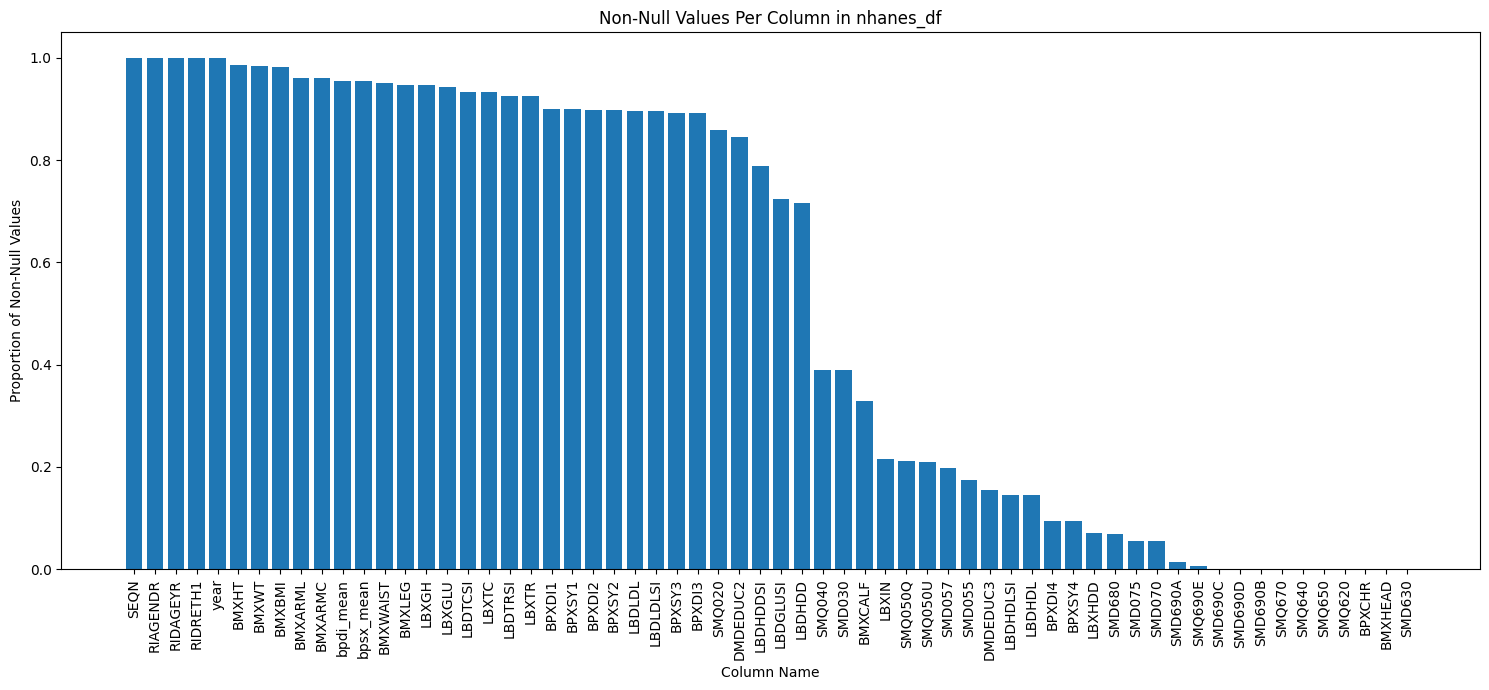

In [ ]:
not_na_proportion(nhanes_df, 'nhanes_df')

This shows many potential features well represented in the dataset we can use for ML. Let's drop features below a desired threshold before moving forward.

In [ ]:
def drop_na_below_fraction(df,frac):
  df = df[[c for c in df.columns if df[c].notna().mean()>frac]]
  return df

In [ ]:
nhanes_df = drop_na_below_fraction(nhanes_df, 0.6)

### Check for non-numeric data

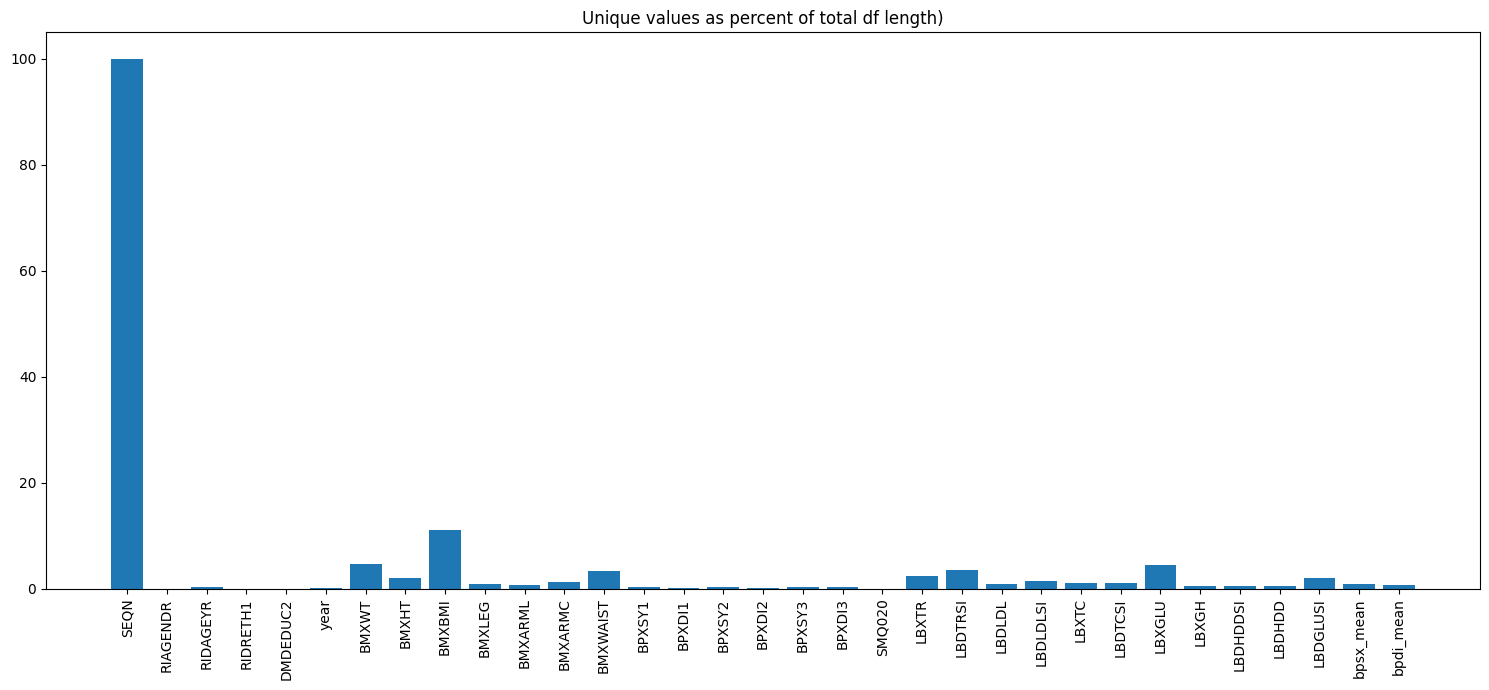

In [ ]:
  plt.figure(figsize=(15, 7))
  plt.bar(x=nhanes_df.nunique().index,
          height=nhanes_df.nunique()/len(nhanes_df)*100)
  plt.xticks(rotation=90)
  plt.title('Unique values as percent of total df length)')
  plt.tight_layout()
  plt.show()

In [ ]:
#Use heuristic of unique count < 0.1% of dataframe length
non_numeric = nhanes_df.nunique()*1000<len(nhanes_df)
non_numeric = non_numeric[non_numeric].index.tolist()
print(non_numeric)

['RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'year', 'SMQ020']


In [ ]:
#Remove features we don't want to pivot to dummy
non_numeric.remove('year')
non_numeric.remove('RIAGENDR')

In [ ]:
#Save nodummy version first
nhanes_df.to_csv(f'{base_path}nhanes_df_nodummy.csv',index=False)

In [ ]:
#Add dummy variables for each
nhanes_df = pd.get_dummies(nhanes_df,columns=non_numeric,dummy_na=True)
nhanes_df.head()

,SEQN,RIAGENDR,RIDAGEYR,year,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,...,DMDEDUC2_4.0,DMDEDUC2_5.0,DMDEDUC2_7.0,DMDEDUC2_9.0,DMDEDUC2_nan,SMQ020_1.0,SMQ020_2.0,SMQ020_7.0,SMQ020_9.0,SMQ020_nan
0,2.0,1.0,77.0,1999,75.4,174.0,24.90,NaN,38.2,29.8,...,False,True,False,False,False,False,True,False,False,False
1,5.0,1.0,49.0,1999,92.5,178.3,29.10,45.2,39.7,35.8,...,False,True,False,False,False,True,False,False,False,False
2,7.0,2.0,59.0,1999,78.0,162.9,29.39,43.0,38.1,31.7,...,False,False,False,False,False,True,False,False,False,False
3,10.0,1.0,43.0,1999,111.8,190.1,30.94,46.6,43.0,37.6,...,False,False,False,False,False,True,False,False,False,False
4,12.0,1.0,37.0,1999,99.2,180.0,30.62,46.0,40.0,37.2,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
#Dump to CSV
nhanes_df.to_csv(f'{base_path}nhanes_df.csv',index=False)

In [ ]:
#Print feature list (for data descriptio in report)
nhanes_df.columns

Index(['SEQN', 'RIAGENDR', 'RIDAGEYR', 'year', 'BMXWT', 'BMXHT', 'BMXBMI',
       'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST', 'BPXSY1', 'BPXDI1',
       'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'LBXTR', 'LBDTRSI', 'LBDLDL',
       'LBDLDLSI', 'LBXTC', 'LBDTCSI', 'LBXGLU', 'LBXGH', 'LBDHDDSI', 'LBDHDD',
       'LBDGLUSI', 'bpsx_mean', 'bpdi_mean', 'RIDRETH1_1.0', 'RIDRETH1_2.0',
       'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0', 'RIDRETH1_nan',
       'DMDEDUC2_1.0', 'DMDEDUC2_2.0', 'DMDEDUC2_3.0', 'DMDEDUC2_4.0',
       'DMDEDUC2_5.0', 'DMDEDUC2_7.0', 'DMDEDUC2_9.0', 'DMDEDUC2_nan',
       'SMQ020_1.0', 'SMQ020_2.0', 'SMQ020_7.0', 'SMQ020_9.0', 'SMQ020_nan'],
      dtype='object')

#Merge Wonder and NHANES

In [ ]:
wonder_df = pd.read_csv(f'{base_path}wonder_df.csv')
nhanes_df = pd.read_csv(f'{base_path}nhanes_df.csv')

In [ ]:
#wonder is annual while NHANES covers 2-year periods starting with odd years.
#need to avegrage wonder into 2-year groups
wonder_df['nhanes_cycle'] = wonder_df['year'].apply(lambda x: x+1 if x%2==0 else x)
wonder_df = wonder_df.groupby(by=['nhanes_cycle','age','gender'],as_index=False).agg('mean')

#rename cycle to year for simplicity
wonder_df['year'] = wonder_df['nhanes_cycle']
wonder_df = wonder_df.drop('nhanes_cycle',axis=1)

In [ ]:
#Age
wonder_df['RIDAGEYR'] = wonder_df['age']
wonder_df['RIAGENDR'] = wonder_df['gender']

wonder_df.head()


,age,gender,year,deaths,crude_rate_per_100k,population,RIDAGEYR,RIAGENDR
0,0.0,1,1999,15646.0,804.984876,1943639.0,0.0,1
1,0.0,2,1999,12291.0,663.616833,1852123.0,0.0,2
2,1.0,1,1999,1103.0,56.975554,1935918.0,1.0,1
3,1.0,2,1999,886.0,47.913388,1849170.0,1.0,2
4,2.0,1,1999,797.0,41.229562,1933079.0,2.0,1


In [ ]:
#Group Nhanes
on_cols = ['year','RIDAGEYR','RIAGENDR']
agg_cols = [x for x in nhanes_df.columns.tolist() if x not in on_cols]
agg_func = {x:'mean' for x in agg_cols}
agg_func['SEQN'] = 'count'
nhanes_grouped = nhanes_df.groupby(by=on_cols,as_index=False).agg(agg_func)

In [ ]:
#Merge
merged_df = pd.merge(wonder_df,nhanes_grouped, on=['year','RIDAGEYR','RIAGENDR'])

In [ ]:
merged_df.shape

(1372, 54)

## Inspect Dataframe

In [ ]:
#merged_df = pd.read_csv(f'{base_path}merged_df.csv')

In [ ]:
display(merged_df.tail()),merged_df.shape

,age,gender,year,deaths,crude_rate_per_100k,population,RIDAGEYR,RIAGENDR,SEQN,BMXWT,...,DMDEDUC2_4.0,DMDEDUC2_5.0,DMDEDUC2_7.0,DMDEDUC2_9.0,DMDEDUC2_nan,SMQ020_1.0,SMQ020_2.0,SMQ020_7.0,SMQ020_9.0,SMQ020_nan
1367,78.0,2,2017,29349.0,3303.577634,888358.5,78.0,2,11,77.970000,...,0.181818,0.090909,0.0,0.000000,0.0,0.363636,0.636364,0.0,0.0,0.0
1368,79.0,1,2017,33103.0,5122.189729,646278.0,79.0,1,10,72.510000,...,0.100000,0.300000,0.0,0.000000,0.0,0.700000,0.300000,0.0,0.0,0.0
1369,79.0,2,2017,30570.0,3670.395469,832947.0,79.0,2,9,64.762500,...,0.222222,0.333333,0.0,0.000000,0.0,0.555556,0.444444,0.0,0.0,0.0
1370,80.0,1,2017,33393.5,5654.918954,590514.0,80.0,1,87,81.397590,...,0.229885,0.206897,0.0,0.022989,0.0,0.574713,0.425287,0.0,0.0,0.0
1371,80.0,2,2017,32109.5,4127.934785,777863.0,80.0,2,94,68.769231,...,0.297872,0.148936,0.0,0.000000,0.0,0.361702,0.638298,0.0,0.0,0.0


(None, (1372, 54))

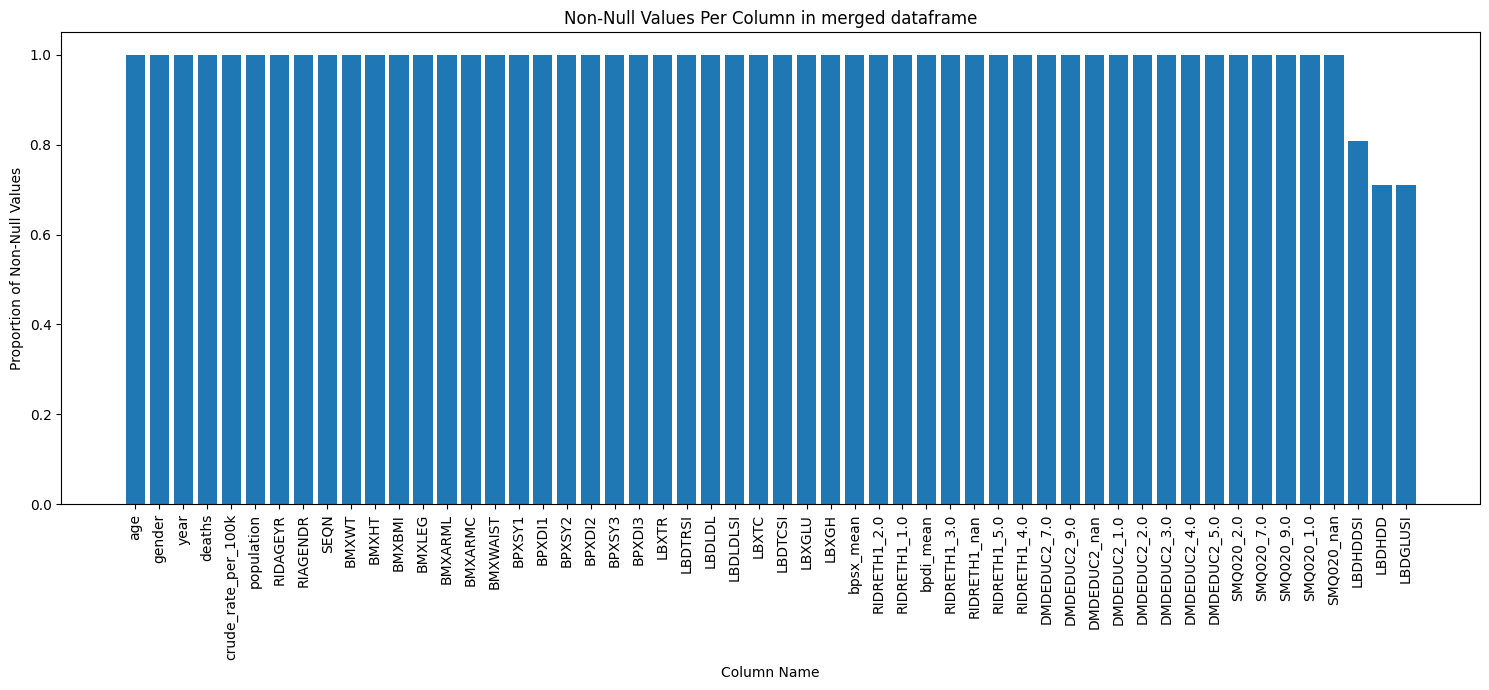

In [ ]:
not_na_proportion(merged_df, 'merged dataframe')

In [ ]:
#Fill remaining missing values using nearest gender/age/year match
merged_df = merged_df.sort_values(by=['gender','age','year']).ffill()

In [ ]:
#Dump final df to csv
merged_df.to_csv(f'{base_path}merged_df.csv',index=False)

This dataframe appears more 'full' than nhanes_df because we've grouped/averaged NHANES into demographic groups.

WONDER 'not applicable' have not been set to nan, which makes population appear more full than it is.

# Merge NHANES and NDI Mortality

In [ ]:
nhanes_df = pd.read_csv(f'{base_path}nhanes_df_nodummy.csv')
mort_df = pd.read_csv(f'{base_path}mort_df.csv')
nhanes_ndi_df = pd.merge(mort_df,nhanes_df)


In [ ]:
nhanes_ndi_df

,SEQN,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM,year,RIAGENDR,...,LBDLDLSI,LBXTC,LBDTCSI,LBXGLU,LBXGH,LBDHDDSI,LBDHDD,LBDGLUSI,bpsx_mean,bpdi_mean
0,2,1,1.0,6.0,0.0,0.0,177.0,177.0,1999,1.0,...,3.520,215.0,5.56,83.7,4.7,NaN,NaN,NaN,100.666667,56.666667
1,5,1,0.0,NaN,NaN,NaN,244.0,244.0,1999,1.0,...,4.340,279.0,7.21,99.9,5.5,NaN,NaN,NaN,122.000000,82.666667
2,7,1,0.0,NaN,NaN,NaN,237.0,236.0,1999,2.0,...,3.280,245.0,6.34,85.6,5.8,NaN,NaN,NaN,125.333333,80.000000
3,10,1,1.0,1.0,0.0,0.0,231.0,231.0,1999,1.0,...,2.070,140.0,3.62,89.8,5.5,NaN,NaN,NaN,145.333333,96.000000
4,12,1,0.0,NaN,NaN,NaN,236.0,236.0,1999,1.0,...,2.300,156.0,4.03,82.9,5.2,NaN,NaN,NaN,176.666667,102.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29981,102947,1,0.0,NaN,NaN,NaN,31.0,31.0,2017,1.0,...,1.707,143.0,3.70,85.0,5.8,1.81,70.0,4.72,154.000000,80.000000
29982,102948,1,0.0,NaN,NaN,NaN,14.0,14.0,2017,2.0,...,3.181,209.0,5.40,92.0,5.2,1.97,76.0,5.11,87.333333,64.666667
29983,102952,1,0.0,NaN,NaN,NaN,35.0,34.0,2017,2.0,...,1.112,119.0,3.08,158.0,7.4,1.55,60.0,8.77,139.333333,73.333333
29984,102954,1,0.0,NaN,NaN,NaN,17.0,17.0,2017,2.0,...,2.793,172.0,4.45,94.0,5.2,1.40,54.0,5.22,116.000000,70.666667


### Inspect dataframe

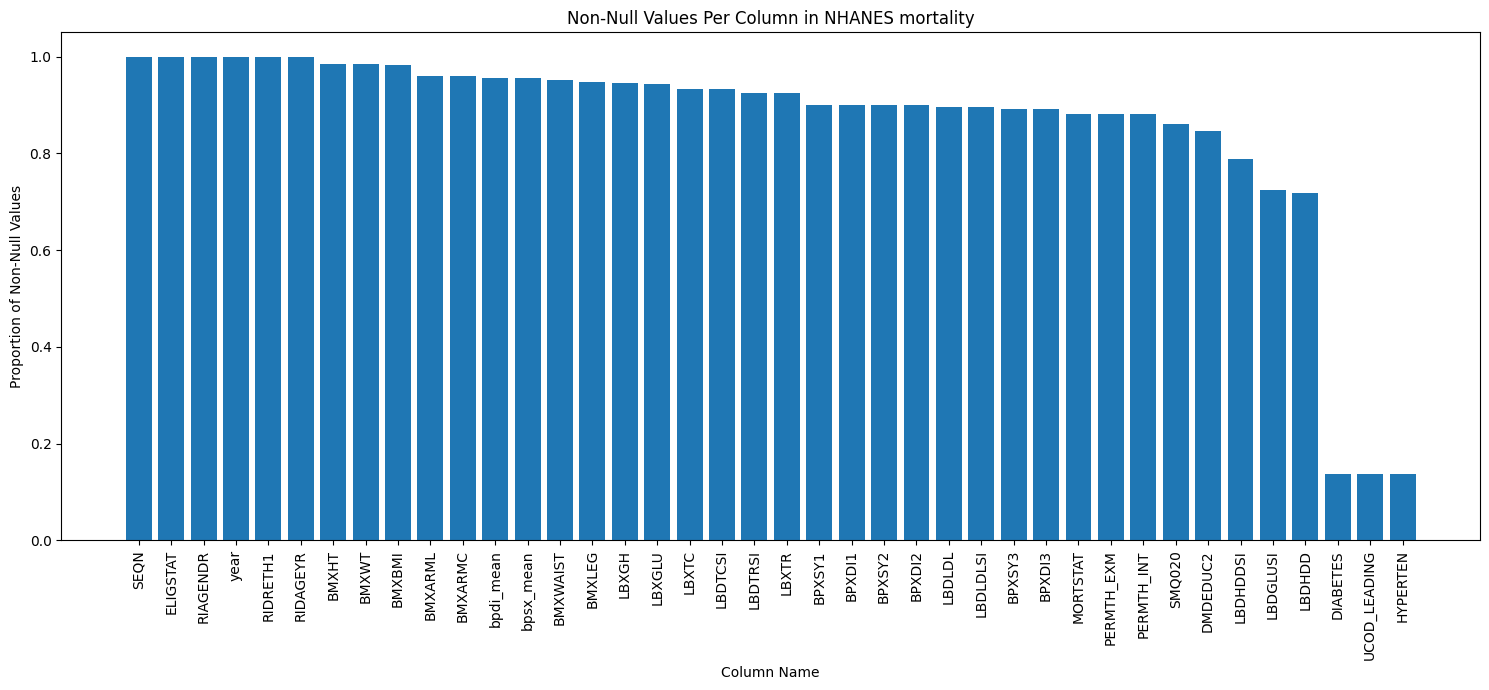

In [ ]:
not_na_proportion(nhanes_ndi_df, 'NHANES mortality')

In [ ]:
#Drop rows without mortstat
nhanes_ndi_df = nhanes_ndi_df[nhanes_ndi_df['MORTSTAT'].notna()]
#Drop rows <60% full
nhanes_ndi_df = drop_na_below_fraction(nhanes_ndi_df, 0.6)
nhanes_ndi_df.shape

(26453, 37)

In [ ]:
#Dump to CSV
nhanes_ndi_df.to_csv(f'{base_path}nhanes_ndi_df.csv',index=False)

In [ ]:
nhanes_ndi_df.shape

(26453, 37)